### 📊 AED para explorar a Efetividade do Programa

**Base:** `df_base_2.parquet` — atualização gerada no Notebook `03_AED_IEG.ipynb`.

**❓Pergunta chave:**
- Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

**Sub-perguntas:**
- Como a distribuição de pedras evolui ao longo dos anos?
- Alunos que permanecem no programa melhoram de pedra ao longo do tempo?
- O tempo no programa influencia o desempenho?
- Os indicadores individuais melhoram ao longo do ciclo?

### ⚙️ Import e Setup

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_parquet('../data/processed/df_base_2.parquet')

print(f'df_base: {df.shape[0]} linhas | {df.shape[1]} colunas')

df_base: 3030 linhas | 31 colunas


In [18]:
df.columns

Index(['ano', 'RA', 'nome', 'genero', 'idade', 'ano_ingresso', 'instituicao',
       'fase', 'turma', 'nivel', 'fase_ideal', 'defasagem', 'pedra', 'INDE',
       'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'mat', 'por', 'ing',
       'indicado_bolsa', 'atingiu_pv', 'rec_psicologia', 'pedra_20',
       'pedra_21', 'pedra_22', 'pedra_23'],
      dtype='object')

### Distribuição de pedras por ano

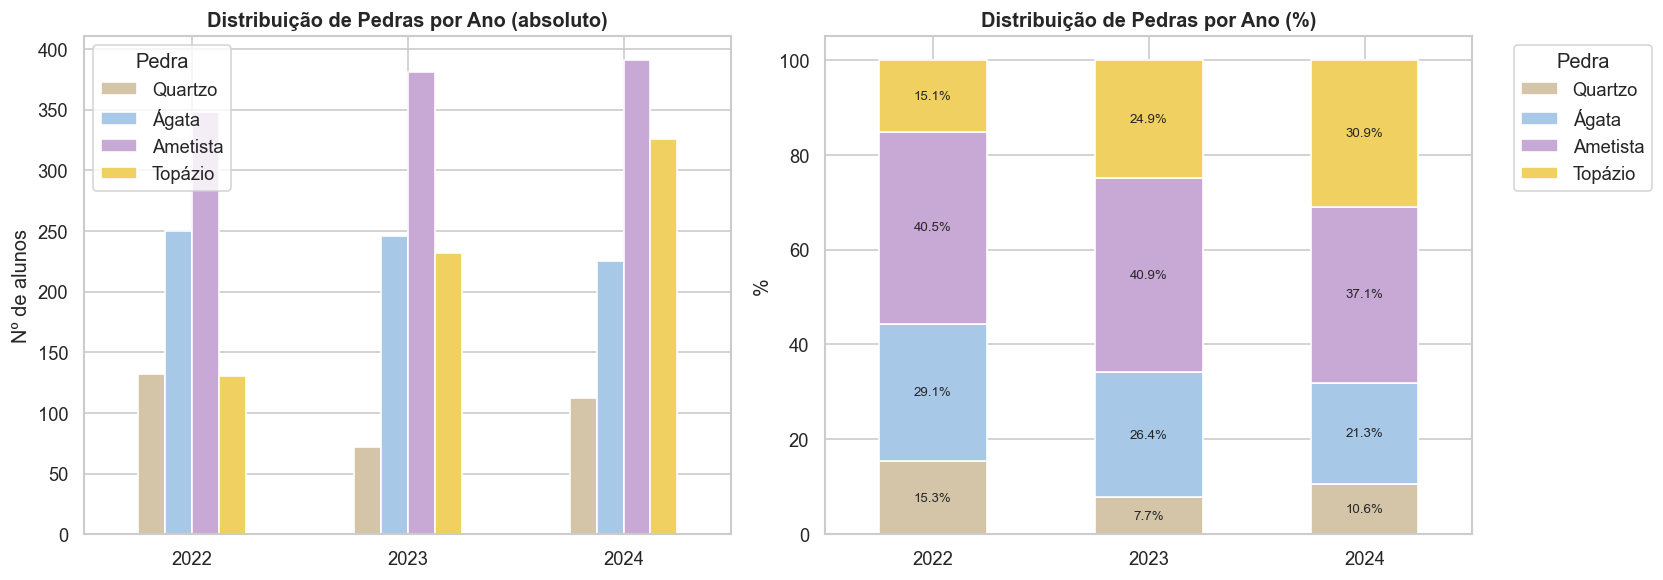

=== Distribuição de pedras por ano (%) ===
pedra  Quartzo  Ágata  Ametista  Topázio
ano                                     
2022      15.3   29.1      40.5     15.1
2023       7.7   26.4      40.9     24.9
2024      10.6   21.3      37.1     30.9

=== Totais absolutos ===
pedra  Quartzo  Ágata  Ametista  Topázio
ano                                     
2022       132    250       348      130
2023        72    246       381      232
2024       112    225       391      326


In [11]:
# Distribuição de pedras por ano
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
cores_pedras = {'Quartzo': '#d4c5a9', 'Ágata': '#a8c8e8', 'Ametista': '#c8a8d4', 'Topázio': '#f0d060'}

df_pedras = df[df['pedra'].isin(ordem_pedras)].copy()

ct = pd.crosstab(df_pedras['ano'], df_pedras['pedra'])[ordem_pedras]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absoluto
ct.plot(kind='bar', ax=axes[0], color=[cores_pedras[p] for p in ordem_pedras])
axes[0].set_title('Distribuição de Pedras por Ano (absoluto)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nº de alunos')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Pedra')

# Percentual empilhado
ct_pct.plot(kind='bar', stacked=True, ax=axes[1], color=[cores_pedras[p] for p in ordem_pedras])
axes[1].set_title('Distribuição de Pedras por Ano (%)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Pedra', bbox_to_anchor=(1.05, 1))

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

print('=== Distribuição de pedras por ano (%) ===')
print(ct_pct.round(1).to_string())
print(f'\n=== Totais absolutos ===')
print(ct.to_string())

##### 💡 Insight

**Topázio dobrou:** de 15.1% (2022) para 30.9% (2024)
- crescimento consistente ano a ano

**Quartzo diminuiu:** de 15.3% para 10.6%
- menos alunos na faixa mais baixa

**Ágata caindo gradualmente:** de 29.1% para 21.3%
- alunos migrando para Ametista/Topázio

**Ametista estável** (~37-41%)
- funciona como zona de transição

A subida do Quartzo em 2024 (7.7% → 10.6%) pode ser efeito de alunos novos entrando com INDE mais baixo

❓ Os mesmos alunos estão subindo de pedra ao longo do tempo, ou a melhora é por causa de novos alunos entrando com nota mais alta?

### Evolução de pedras dos alunos longitudinais

Alunos com pedra em 2022 e 2024: 445

Evolução de pedra (2022 -> 2024):
  Manteve   :  199 (44.7%)
  Subiu     :  132 (29.7%)
  Caiu      :  114 (25.6%)


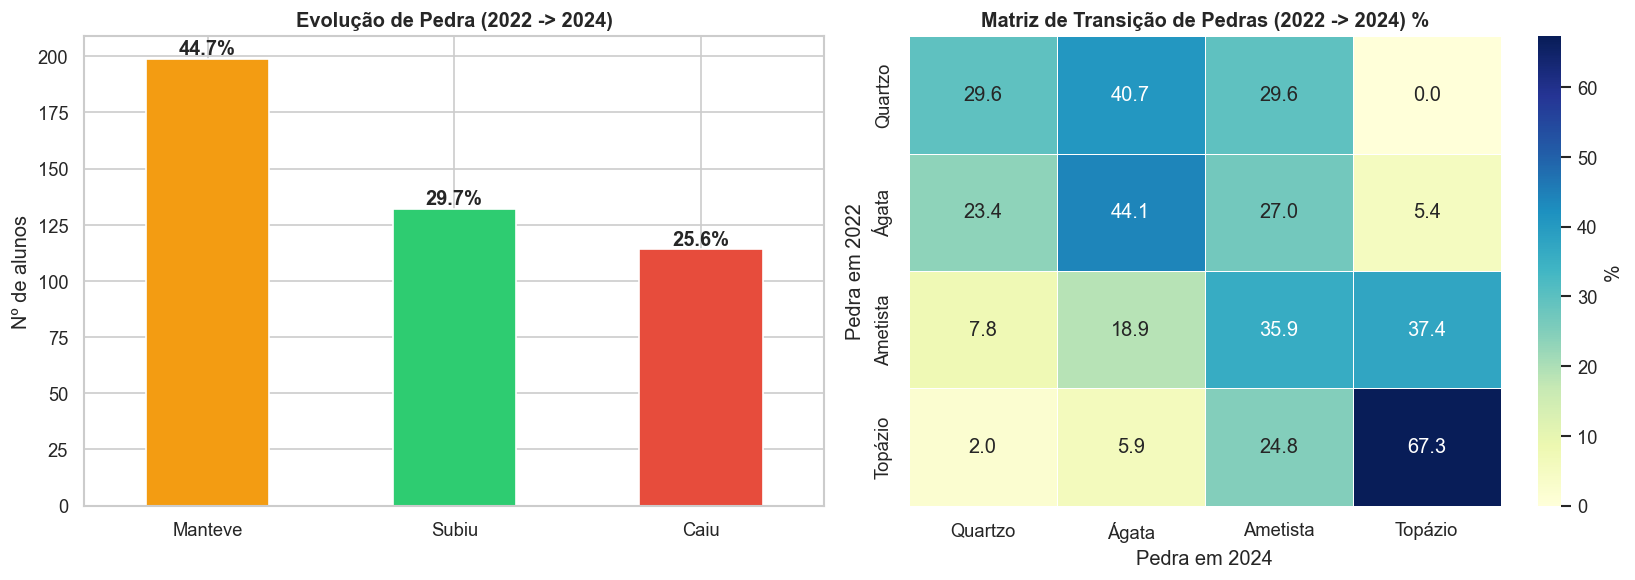

In [13]:
# Evolução de pedras: alunos presentes em 2022 e 2024
df_evol = df[df['pedra'].isin(ordem_pedras)].copy()

# Pegar pedra de cada ano por aluno
pivot_pedra = df_evol.pivot_table(index='RA', columns='ano', values='pedra', aggfunc='first')

# Alunos com pedra em 2022 e 2024
alunos_22_24 = pivot_pedra[[2022, 2024]].dropna()
print(f'Alunos com pedra em 2022 e 2024: {len(alunos_22_24)}')

# Mapear pedra para valor numérico para calcular evolução
mapa_pedra_num = {'Quartzo': 1, 'Ágata': 2, 'Ametista': 3, 'Topázio': 4}

alunos_22_24['num_2022'] = alunos_22_24[2022].map(mapa_pedra_num)
alunos_22_24['num_2024'] = alunos_22_24[2024].map(mapa_pedra_num)
alunos_22_24['delta'] = alunos_22_24['num_2024'] - alunos_22_24['num_2022']

alunos_22_24['evolucao'] = alunos_22_24['delta'].apply(
    lambda d: 'Subiu' if d > 0 else ('Caiu' if d < 0 else 'Manteve'))

ev = alunos_22_24['evolucao'].value_counts()
print(f'\nEvolução de pedra (2022 -> 2024):')
for e, n in ev.items():
    print(f'  {e:10}: {n:4d} ({n/len(alunos_22_24)*100:.1f}%)')

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de evolução
cores_ev = {'Subiu': '#2ecc71', 'Manteve': '#f39c12', 'Caiu': '#e74c3c'}
ev.plot(kind='bar', ax=axes[0], color=[cores_ev[e] for e in ev.index])
axes[0].set_title('Evolução de Pedra (2022 -> 2024)', fontweight='bold')
axes[0].set_ylabel('Nº de alunos')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

for i, (e, n) in enumerate(ev.items()):
    axes[0].text(i, n + 2, f'{n/len(alunos_22_24)*100:.1f}%', ha='center', fontweight='bold')

# Matriz de transição: de qual pedra para qual
transicao = pd.crosstab(alunos_22_24[2022], alunos_22_24[2024])
transicao = transicao.reindex(index=ordem_pedras, columns=ordem_pedras, fill_value=0)
transicao_pct = transicao.div(transicao.sum(axis=1), axis=0) * 100

sns.heatmap(transicao_pct, annot=True, fmt='.1f', cmap='YlGnBu',
            ax=axes[1], cbar_kws={'label': '%'}, linewidths=0.5)
axes[1].set_title('Matriz de Transição de Pedras (2022 -> 2024) %', fontweight='bold')
axes[1].set_xlabel('Pedra em 2024')
axes[1].set_ylabel('Pedra em 2022')

plt.tight_layout()
plt.show()

##### 💡 Insights

**29.7% dos alunos subiram de pedra, 44.7% mantiveram, 25.6% caíram**
— balanço levemente positivo

**Destaques da matriz de transição:**
- **70.4% dos alunos do Quartzo saíram** da faixa mais baixa em 2 anos (40.7% → Ágata, 29.6% → Ametista)
- **37.4% da Ametista subiram para Topázio** — a transição mais promissora
- **Topázio retém 67.3%** dos alunos — quanto mais alto, mais difícil cair
- Nenhum aluno do Quartzo saltou direto para Topázio em 2 anos

**Padrão geral:** a mobilidade ascendente é real — a maioria dos alunos nas faixas mais baixas progride. Mas a queda também existe (25.6%), especialmente na Ágata (23.4% caiu para Quartzo)

❓ O tempo que o aluno está no programa influencia o seu desempenho (INDE)?

### Tempo no programa X Desempenho

=== INDE médio por tempo no programa ===
                INDE_medio     n
tempo_programa                  
0                     7.33  1108
1                     7.32   643
2                     7.34   340
3                     7.22   437
4                     7.06   160
5                     6.85    85
6                     7.00    56
7                     6.91    16


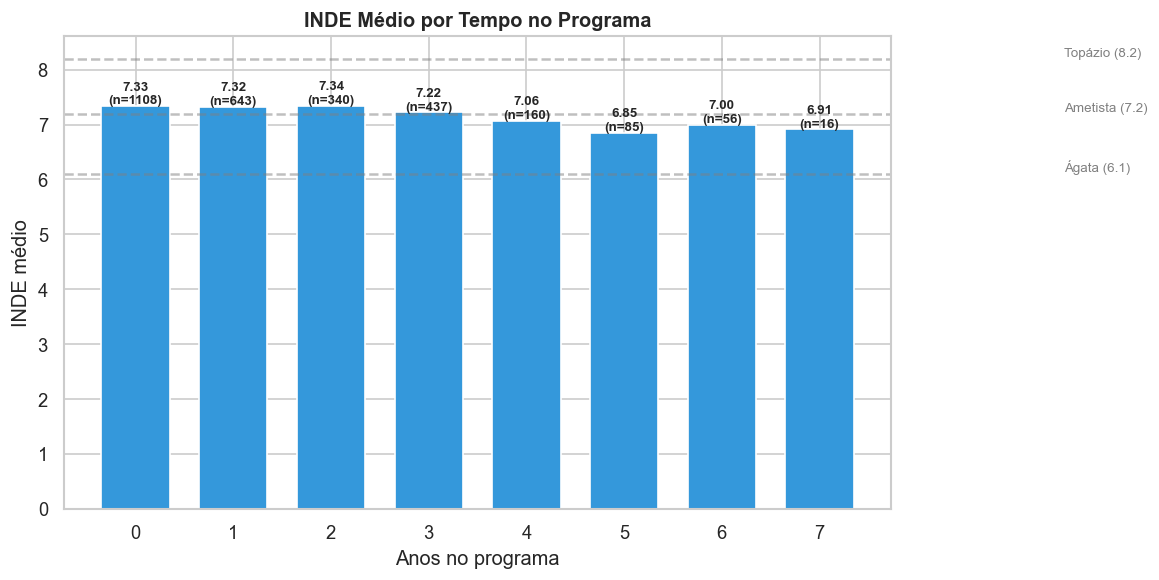

In [14]:
# Tempo no programa influencia o desempenho?
df_tempo = df[df['ano_ingresso'].notna() & df['INDE'].notna()].copy()
df_tempo['tempo_programa'] = df_tempo['ano'] - df_tempo['ano_ingresso']

# Filtrar tempos razoáveis (0 a 10 anos)
df_tempo = df_tempo[(df_tempo['tempo_programa'] >= 0) & (df_tempo['tempo_programa'] <= 10)]

# INDE médio por tempo no programa
resumo_tempo = df_tempo.groupby('tempo_programa')['INDE'].agg(['mean', 'count']).round(2)
resumo_tempo.columns = ['INDE_medio', 'n']

print('=== INDE médio por tempo no programa ===')
print(resumo_tempo.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(resumo_tempo.index, resumo_tempo['INDE_medio'], color='#3498db', width=0.7)
ax.set_xlabel('Anos no programa')
ax.set_ylabel('INDE médio')
ax.set_title('INDE Médio por Tempo no Programa', fontweight='bold')
ax.set_xticks(range(int(resumo_tempo.index.max()) + 1))

for i, (tempo, row) in enumerate(resumo_tempo.iterrows()):
    ax.text(tempo, row['INDE_medio'] + 0.05, f'{row["INDE_medio"]:.2f}\n(n={int(row["n"])})',
            ha='center', fontsize=8, fontweight='bold')

# Linha de referência das pedras
ax.axhline(6.1, color='gray', linestyle='--', alpha=0.5)
ax.text(9.5, 6.15, 'Ágata (6.1)', fontsize=8, color='gray')
ax.axhline(7.2, color='gray', linestyle='--', alpha=0.5)
ax.text(9.5, 7.25, 'Ametista (7.2)', fontsize=8, color='gray')
ax.axhline(8.2, color='gray', linestyle='--', alpha=0.5)
ax.text(9.5, 8.25, 'Topázio (8.2)', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

##### 💡 Insights

**O tempo no programa, isoladamente, não mostra relação clara com melhora do INDE.**
- As médias ficam praticamente estáveis entre `0` e `2` anos (`~7.32–7.34`) e depois tendem a cair.

**Não aparece um padrão de ganho acumulado ao longo da permanência.**
- Se o impacto fosse linear no tempo, seria esperado um crescimento progressivo do INDE, o que não ocorre.

**Esse resultado complementa as análises anteriores.**
- A efetividade do programa aparece melhor na mobilidade de pedras e na evolução longitudinal dos mesmos alunos do que no tempo bruto de permanência.

**Os grupos com mais anos no programa devem ser interpretados com cautela.**
- As amostras são menores e podem refletir perfis mais desafiadores, o que limita uma leitura causal direta.

### Evolução dos indicadores dos mesmo alunos ao longo dos anos

=== Evolução dos indicadores (mesmos alunos, 2022 → 2024) ===
      media  mediana  pct_subiu  pct_caiu      n
IDA   -0.47    -0.35      43.60     55.51  445.0
IEG   -0.55    -0.15      43.15     55.06  445.0
IAA   -0.03     0.00      50.11     49.21  445.0
IPS   -0.18     0.01      63.15     36.63  445.0
IPP    1.20     1.25      77.75     20.22  445.0
IPV   -0.23    -0.17      42.02     57.53  445.0
INDE   0.00     0.07      55.06     44.94  445.0


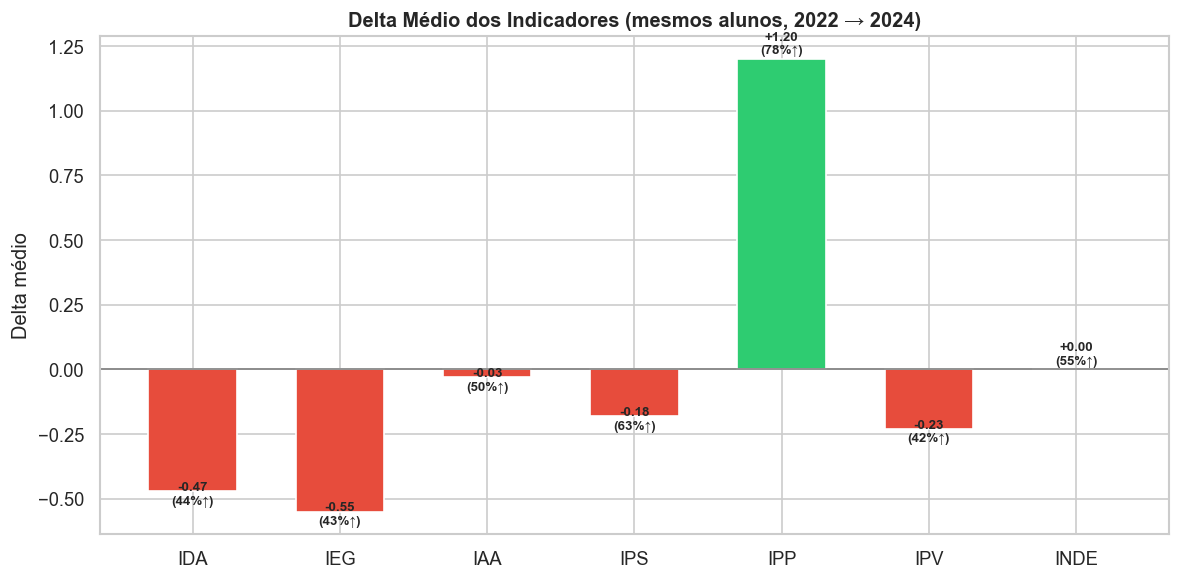

In [15]:
# Evolução dos indicadores dos mesmos alunos entre 2022 e 2024
indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']

alunos_22_24_ind = df[df['ano'].isin([2022, 2024])].groupby('RA').filter(lambda x: x['ano'].nunique() == 2)

deltas = {}
for ind in indicadores:
    pivot = alunos_22_24_ind.pivot_table(index='RA', columns='ano', values=ind, aggfunc='first').dropna()
    if len(pivot) > 0:
        delta = pivot[2024] - pivot[2022]
        deltas[ind] = {
            'media': delta.mean(),
            'mediana': delta.median(),
            'pct_subiu': (delta > 0).mean() * 100,
            'pct_caiu': (delta < 0).mean() * 100,
            'n': len(delta)
        }

df_deltas = pd.DataFrame(deltas).T.round(2)
print('=== Evolução dos indicadores (mesmos alunos, 2022 → 2024) ===')
print(df_deltas.to_string())

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))

cores_delta = ['#2ecc71' if v > 0 else '#e74c3c' for v in df_deltas['media']]
ax.bar(df_deltas.index, df_deltas['media'], color=cores_delta, width=0.6)
ax.axhline(0, color='gray', linestyle='-', linewidth=1)
ax.set_title('Delta Médio dos Indicadores (mesmos alunos, 2022 → 2024)', fontweight='bold')
ax.set_ylabel('Delta médio')
ax.set_xlabel('')

for i, (ind, row) in enumerate(df_deltas.iterrows()):
    ax.text(i, row['media'] + 0.02 if row['media'] >= 0 else row['media'] - 0.05,
            f'{row["media"]:+.2f}\n({row["pct_subiu"]:.0f}%↑)',
            ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

### Evolução dos indicadores por pedra inicial

=== Delta médio dos indicadores por pedra inicial (2022 -> 2024) ===
            delta_IDA  delta_IEG  delta_IAA  delta_IPS  delta_IPP  delta_IPV  delta_INDE
pedra_2022                                                                              
Quartzo          1.95       0.58       1.84       0.49       1.42       0.71        1.10
Ágata           -0.23      -0.85       0.07      -0.02       0.83      -0.20       -0.02
Ametista        -0.68      -0.70      -0.25      -0.24       1.33      -0.29       -0.05
Topázio         -0.94      -0.21      -0.20      -0.42       1.29      -0.38       -0.17

=== Quantidade de alunos por pedra inicial ===
pedra_2022
Quartzo      31
Ágata       117
Ametista    218
Topázio     106


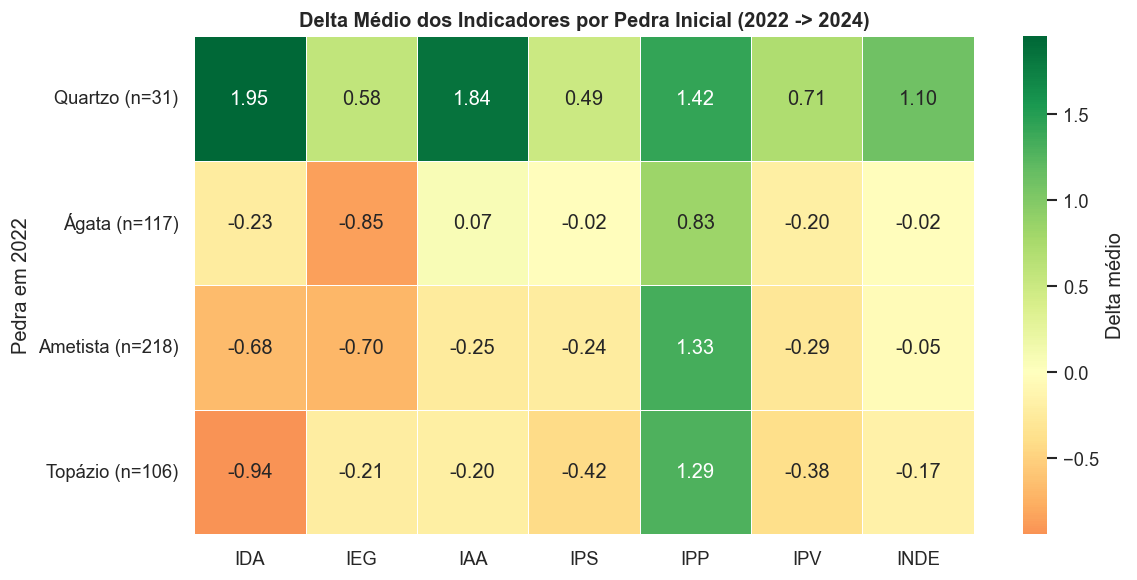

In [16]:
# Evolução dos indicadores dos mesmos alunos, segmentada pela pedra de entrada em 2022
indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']

# Base longitudinal: mesmos alunos com dados em 2022 e 2024
df_long = df[df['ano'].isin([2022, 2024])].copy()
alunos_22_24 = df_long.groupby('RA').filter(lambda x: x['ano'].nunique() == 2).copy()

# Pedra inicial do aluno em 2022
base_ref = (
    alunos_22_24[alunos_22_24['ano'] == 2022][['RA', 'pedra']]
    .rename(columns={'pedra': 'pedra_2022'})
    .drop_duplicates('RA')
    .set_index('RA')
)

# Delta dos indicadores: 2024 - 2022
deltas = {}
for ind in indicadores:
    pivot = alunos_22_24.pivot_table(index='RA', columns='ano', values=ind, aggfunc='first')
    deltas[ind] = pivot[2024] - pivot[2022]

df_delta_pedra = base_ref.join(pd.DataFrame(deltas).add_prefix('delta_'))

# Resumo por pedra inicial
colunas_delta = [f'delta_{ind}' for ind in indicadores]
resumo_pedra = (
    df_delta_pedra.groupby('pedra_2022')[colunas_delta]
    .mean()
    .reindex(ordem_pedras)
    .round(2)
)

n_pedra = (
    df_delta_pedra.groupby('pedra_2022')
    .size()
    .reindex(ordem_pedras)
)

print('=== Delta médio dos indicadores por pedra inicial (2022 -> 2024) ===')
print(resumo_pedra.to_string())
print('\n=== Quantidade de alunos por pedra inicial ===')
print(n_pedra.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    resumo_pedra.rename(columns=lambda c: c.replace('delta_', '')),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Delta médio'}
)

ax.set_title('Delta Médio dos Indicadores por Pedra Inicial (2022 -> 2024)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Pedra em 2022')

# Adiciona n ao eixo y
ax.set_yticklabels([f'{p} (n={int(n_pedra[p])})' if pd.notna(n_pedra[p]) else p for p in resumo_pedra.index], rotation=0)

plt.tight_layout()
plt.show()


##### 💡 Insights

**A efetividade do programa não é uniforme entre as pedras iniciais.**
- Os ganhos variam bastante conforme o ponto de partida do aluno no ciclo.

**O maior avanço aparece entre os alunos que começaram no `Quartzo`.**
- Esse grupo melhora em praticamente todos os indicadores, com destaque para `IDA`, `IAA`, `IPP`, `IPV` e `INDE`.
- Isso sugere maior impacto do programa na faixa mais vulnerável.

**Nas pedras mais altas, o padrão é mais misto.**
- `Ágata`, `Ametista` e `Topázio` mostram melhora clara em `IPP`, mas estabilidade ou queda em vários outros indicadores.
- O `INDE` fica praticamente estável ou levemente negativo nesses grupos.

**O `IPP` é o único indicador que melhora em todas as pedras.**
- Isso reforça a consistência da dimensão psicopedagógica ao longo do ciclo.

**Conclusão curta:** a efetividade parece ser mais forte na base do ciclo e menos uniforme nas pedras mais altas.


### Evolução dos indicadores por fase inicial

=== Delta médio dos indicadores por nível inicial (2022 -> 2024) ===
            delta_IDA  delta_IEG  delta_IAA  delta_IPS  delta_IPP  delta_IPV  delta_INDE
nivel_2022                                                                              
0               -1.00      -0.32      -0.54      -0.41       2.17      -0.38       -0.17
1               -0.94      -1.30       0.03      -0.35       1.37      -0.51       -0.12
2               -0.23      -0.94      -0.11      -0.04       1.11      -0.34        0.02
3                0.53       0.35       0.33      -0.02       0.07       0.54        0.34
4               -0.01      -0.09       0.59       0.08      -0.01       0.06        0.07
5                0.25       0.28       0.53       0.58       0.89      -0.27        0.35
6                 NaN        NaN        NaN        NaN        NaN        NaN         NaN
7                 NaN        NaN        NaN        NaN        NaN        NaN         NaN

=== Quantidade de alunos por nível inici

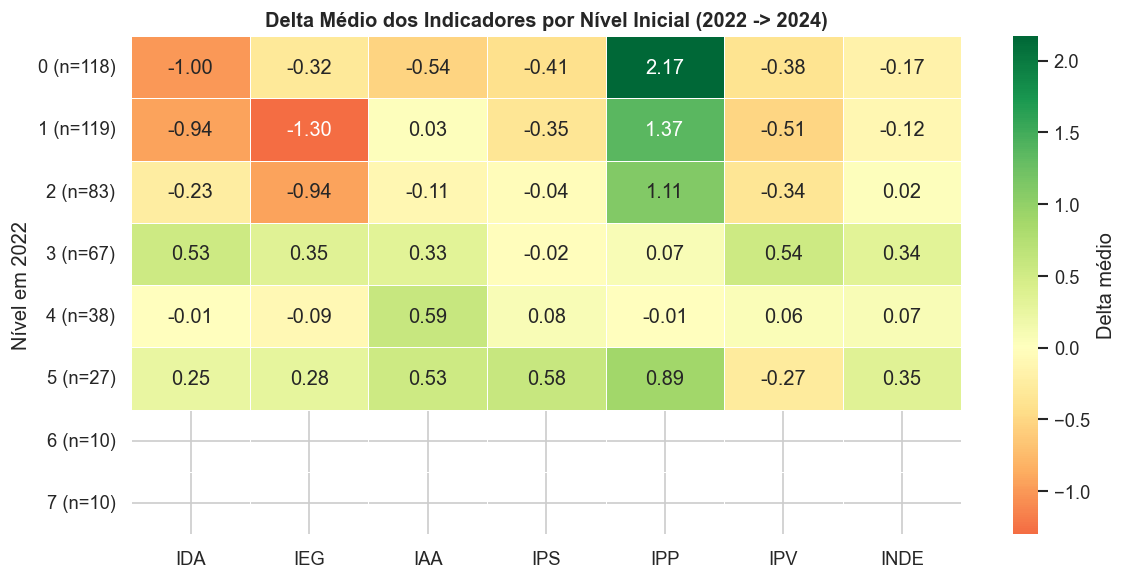

In [17]:
# Evolução dos indicadores dos mesmos alunos, segmentada pela fase/nível inicial em 2022
indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']

# Base longitudinal: mesmos alunos com dados em 2022 e 2024
df_long = df[df['ano'].isin([2022, 2024])].copy()
alunos_22_24 = df_long.groupby('RA').filter(lambda x: x['ano'].nunique() == 2).copy()

# Nível inicial do aluno em 2022
base_ref = (
    alunos_22_24[alunos_22_24['ano'] == 2022][['RA', 'nivel']]
    .rename(columns={'nivel': 'nivel_2022'})
    .drop_duplicates('RA')
    .set_index('RA')
)

# Delta dos indicadores: 2024 - 2022
deltas = {}
for ind in indicadores:
    pivot = alunos_22_24.pivot_table(index='RA', columns='ano', values=ind, aggfunc='first')
    deltas[ind] = pivot[2024] - pivot[2022]

df_delta_nivel = base_ref.join(pd.DataFrame(deltas).add_prefix('delta_'))

# Ordena os níveis numericamente
ordem_niveis = sorted(
    df_delta_nivel['nivel_2022'].dropna().astype(str).unique(),
    key=lambda x: int(x) if str(x).isdigit() else 999
)

# Resumo por nível inicial
colunas_delta = [f'delta_{ind}' for ind in indicadores]
resumo_nivel = (
    df_delta_nivel.groupby('nivel_2022')[colunas_delta]
    .mean()
    .reindex(ordem_niveis)
    .round(2)
)

n_nivel = (
    df_delta_nivel.groupby('nivel_2022')
    .size()
    .reindex(ordem_niveis)
)

print('=== Delta médio dos indicadores por nível inicial (2022 -> 2024) ===')
print(resumo_nivel.to_string())
print('\n=== Quantidade de alunos por nível inicial ===')
print(n_nivel.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    resumo_nivel.rename(columns=lambda c: c.replace('delta_', '')),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Delta médio'}
)

ax.set_title('Delta Médio dos Indicadores por Nível Inicial (2022 -> 2024)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Nível em 2022')

# Adiciona n ao eixo y
ax.set_yticklabels([f'{nvl} (n={int(n_nivel[nvl])})' for nvl in resumo_nivel.index], rotation=0)

plt.tight_layout()
plt.show()


##### 💡 Insights

### ⭐️ Insight Final

texto